# 🧾 Stock-level fundamentals example: profitability factor

## 🧭 tl;dr

This notebook uses the public **Kenneth French Data Library** to study a stock-level fundamentals strategy:

> Go long firms with robust operating profitability and short firms with weak operating profitability.

The downloaded series is the published **RMW (Robust Minus Weak)** factor. It is built from portfolios formed from many NYSE, AMEX, and NASDAQ stocks using accounting data. That makes this a more honest fundamentals example than pulling today’s company fundamentals and pretending they were known in the past.

Important scope limit:

- this is a **published historical factor portfolio**, not a full individual-stock screener built from raw point-in-time filings;
- the notebook documents the formation timing and uses an explicit illustrative cost scenario;
- the factor’s historical returns can be revised when the data library updates its database.

> **Educational research only. Not financial advice.**

## 📚 Research source and point-in-time logic

The official data documentation says:

- operating profitability for June of year t uses revenues, expenses, and book equity from the last fiscal year ending in t−1;
- portfolios are formed at the end of June and held from July of t through June of t+1;
- RMW is the average return of small-robust and big-robust portfolios minus the average return of small-weak and big-weak portfolios.

This timing is important. Accounting data must be lagged; otherwise a backtest can use financial statements before the market could have known them.

Sources:

- [Kenneth French Data Library](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html)
- [Operating Profitability portfolio construction details](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_port_form_op.html)
- [Fama/French 5-factor definitions, including RMW](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/f-f_5_factors_2x3.html)

In [1]:
from pathlib import Path
import sys
from io import BytesIO, StringIO
from urllib.request import urlopen
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import split_time_series
from src.metrics import calculate_metrics

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.width", 140)

## 📥 Download and parse the historical factor file

The source is a ZIP file containing monthly and annual sections. The parser keeps rows with a six-digit YYYYMM label, which selects the monthly history and avoids accidentally mixing annual observations into the monthly strategy.

In [2]:
SOURCE_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_CSV.zip"
)

def load_rmw_monthly():
    raw_bytes = urlopen(SOURCE_URL, timeout=30).read()
    with ZipFile(BytesIO(raw_bytes)) as archive:
        member = archive.namelist()[0]
        text = archive.read(member).decode("latin1")
    raw = pd.read_csv(StringIO(text), skiprows=3)
    period = raw.iloc[:, 0].astype(str).str.strip()
    monthly = raw.loc[period.str.fullmatch(r"\d{6}")].copy()
    monthly["period"] = period.loc[monthly.index]
    monthly.index = pd.to_datetime(monthly["period"], format="%Y%m")
    monthly.index.name = "month"
    for column in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
        monthly[column] = pd.to_numeric(monthly[column], errors="coerce")
    return monthly[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]].dropna()

def make_demo_factor():
    rng = np.random.default_rng(49)
    dates = pd.date_range("1963-07-01", periods=750, freq="MS")
    market = rng.normal(0.65, 4.5, len(dates))
    rmw = 0.35 + 0.35 * market + rng.normal(0, 2.4, len(dates))
    return pd.DataFrame({
        "Mkt-RF": market,
        "SMB": rng.normal(0, 3, len(dates)),
        "HML": rng.normal(0, 3, len(dates)),
        "RMW": rmw,
        "CMA": rng.normal(0, 2.5, len(dates)),
        "RF": np.full(len(dates), 0.25),
    }, index=dates.rename("month"))

try:
    factors = load_rmw_monthly()
    source_label = f"official Kenneth French monthly 5-factor file ({SOURCE_URL})"
except Exception as exc:
    factors = make_demo_factor()
    source_label = f"deterministic synthetic demonstration data ({type(exc).__name__})"

print(f"Data source: {source_label}")
print(f"Observations: {len(factors):,} monthly | {factors.index.min().date()} to {factors.index.max().date()}")
display(factors.head())

Data source: official Kenneth French monthly 5-factor file (https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip)
Observations: 755 monthly | 1963-07-01 to 2026-05-01


,Mkt-RF,SMB,HML,RMW,CMA,RF
month,,,,,,
1963-07-01,-0.39,-0.48,-0.81,0.64,-1.15,0.27
1963-08-01,5.08,-0.80,1.70,0.40,-0.38,0.25
1963-09-01,-1.57,-0.43,0.00,-0.78,0.15,0.27
1963-10-01,2.54,-1.34,-0.04,2.79,-2.25,0.29
1963-11-01,-0.86,-0.85,1.73,-0.43,2.27,0.27


## 📐 Exact strategy and cost assumption

- **Gross RMW:** use the published monthly RMW return, divided by 100.
- **Market comparator:** (Mkt-RF) + RF, divided by 100.
- **Illustrative net RMW:** subtract a stated cost from a 2.0 gross-exposure long-short sleeve.
- **Cost scenarios:** 0, 5, 10, 25, and 50 basis points per gross-exposure unit per month.

The cost adjustment is intentionally labeled **illustrative**. The public factor file does not provide security-level holdings and turnover for every month, so it cannot support the same turnover accounting as the ETF notebooks. The notebook therefore avoids pretending that a precise executable cost number is known.

In [3]:
gross_rmw = (factors["RMW"] / 100.0).rename("RMW gross")
market = ((factors["Mkt-RF"] + factors["RF"]) / 100.0).rename("market total return")
gross_exposure = 2.0
monthly_turnover_assumption = pd.Series(gross_exposure, index=factors.index, name="illustrative_turnover")

def factor_metrics(returns):
    return dict(calculate_metrics(
        returns,
        benchmark_returns=market.reindex(returns.index).fillna(0.0),
        positions=pd.Series(1.0, index=returns.index),
        turnover=monthly_turnover_assumption.reindex(returns.index),
        annualization=12,
    ))

cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    net = (gross_rmw - gross_exposure * cost_bps / 10_000.0).rename("net_rmw")
    cost_rows.append({"cost_bps_per_exposure_unit": cost_bps, **factor_metrics(net)})
cost_table = pd.DataFrame(cost_rows).set_index("cost_bps_per_exposure_unit")
display(cost_table[[
    "annualized_return", "annualized_volatility", "sharpe_ratio",
    "sortino_ratio", "max_drawdown", "calmar_ratio",
    "annualized_turnover", "benchmark_relative_return",
]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "annualized_turnover": "{:.2f}", "benchmark_relative_return": "{:.2%}"}))

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,annualized_turnover,benchmark_relative_return
cost_bps_per_exposure_unit,,,,,,,,
0,2.67%,7.79%,0.38,0.57,-41.78%,0.06,24.00,-66770.81%
5,1.45%,7.79%,0.22,0.33,-42.85%,0.03,24.00,-67049.44%
10,0.24%,7.79%,0.07,0.10,-43.90%,0.01,24.00,-67180.64%
25,-3.31%,7.79%,-0.39,-0.51,-88.08%,-0.04,24.00,-67285.01%
50,-8.97%,7.79%,-1.16,-1.30,-99.73%,-0.09,24.00,-67296.78%


## 📈 Growth of $1 and drawdowns

The RMW factor is long-short, so its path can differ substantially from the broad equity market. A factor can have a positive average return and still experience long drawdowns or multi-year periods of weakness.

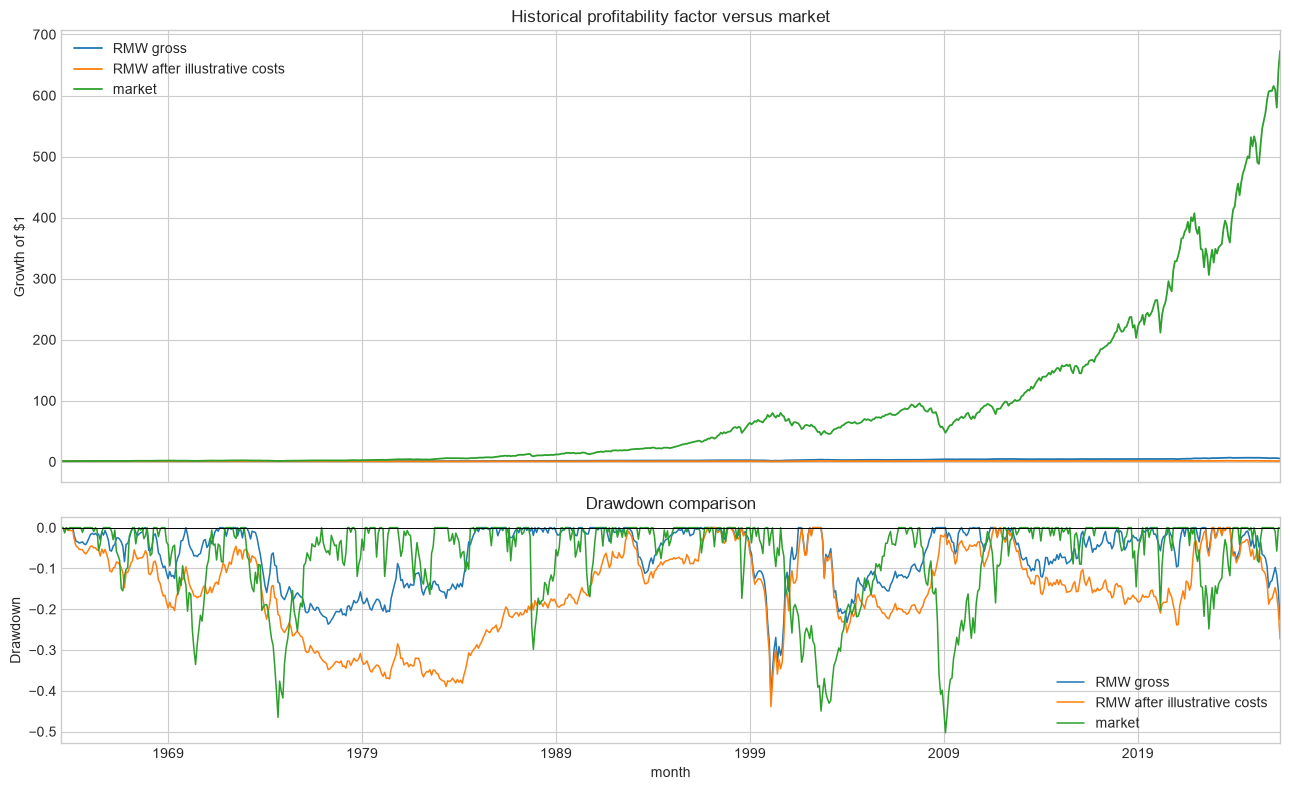

In [4]:
net_rmw = (gross_rmw - gross_exposure * 10 / 10_000.0).rename("RMW after illustrative costs")
equity = pd.DataFrame({
    "RMW gross": (1 + gross_rmw).cumprod(),
    "RMW after illustrative costs": (1 + net_rmw).cumprod(),
    "market": (1 + market).cumprod(),
})
drawdowns = equity / equity.cummax() - 1

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
equity.plot(ax=axes[0], lw=1.3)
axes[0].set_title("Historical profitability factor versus market")
axes[0].set_ylabel("Growth of $1")
drawdowns.plot(ax=axes[1], lw=1.1)
axes[1].set_title("Drawdown comparison")
axes[1].set_ylabel("Drawdown")
axes[1].axhline(0, color="black", lw=0.7)
plt.tight_layout()
plt.show()

## 🔄 Rolling Sharpe and calendar behavior

Rolling Sharpe helps separate a full-sample average from the changing experience of the strategy. The calendar table is descriptive; it is not a new parameter-selection step.

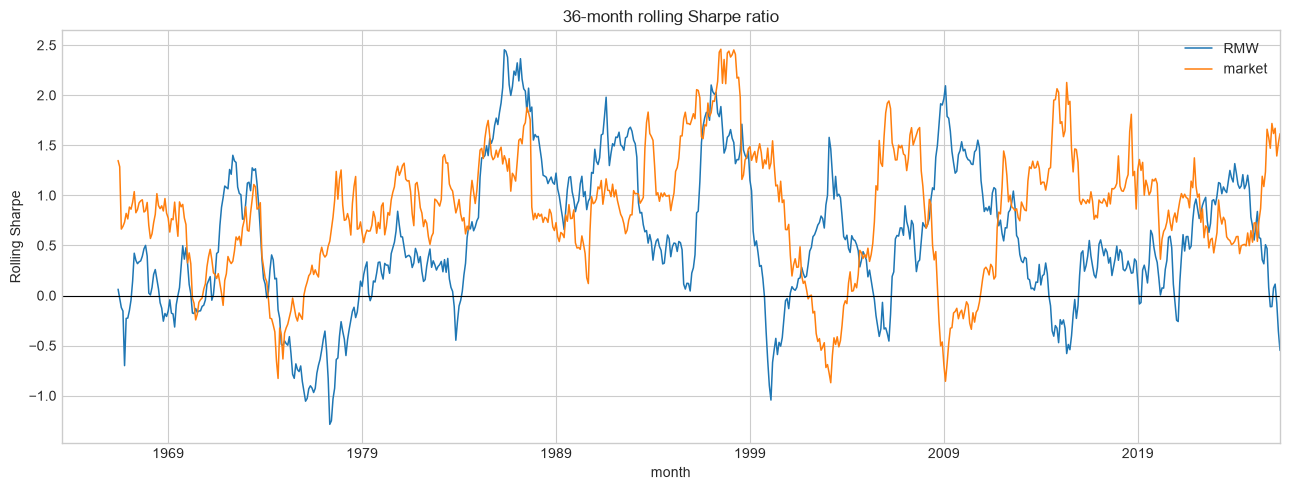

,RMW,market
month,,
2012,-5.23%,16.34%
2013,-3.02%,35.17%
2014,0.60%,11.75%
2015,0.51%,0.25%
2016,3.38%,13.55%
2017,3.79%,22.29%
2018,-1.98%,-5.02%
2019,2.94%,30.54%
2020,-2.28%,24.10%


In [5]:
rolling = pd.DataFrame({
    "RMW": gross_rmw.rolling(36).mean() / gross_rmw.rolling(36).std() * np.sqrt(12),
    "market": market.rolling(36).mean() / market.rolling(36).std() * np.sqrt(12),
})
ax = rolling.plot(figsize=(13, 5), lw=1.1)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("36-month rolling Sharpe ratio")
ax.set_ylabel("Rolling Sharpe")
plt.tight_layout()
plt.show()

calendar = pd.DataFrame({
    "RMW": gross_rmw.groupby(gross_rmw.index.year).apply(lambda x: (1 + x).prod() - 1),
    "market": market.groupby(market.index.year).apply(lambda x: (1 + x).prod() - 1),
})
display(calendar.tail(15).style.format("{:.2%}"))

## 🗓️ Chronological test periods

The factor has a long history, but we still split it chronologically. The final test period is not used to change the rule or cost assumption.

In [6]:
period_frames = split_time_series(pd.DataFrame(index=factors.index))
period_rows = []
for period_name, frame in period_frames.items():
    period_rmw = net_rmw.loc[frame.index]
    period_market = market.loc[frame.index]
    period_rows.append({
        "period": period_name,
        **factor_metrics(period_rmw),
        "market_annualized_return": calculate_metrics(period_market, annualization=12)["annualized_return"],
    })
period_table = pd.DataFrame(period_rows).set_index("period")
display(period_table[[
    "annualized_return", "annualized_volatility", "sharpe_ratio",
    "max_drawdown", "benchmark_relative_return", "market_annualized_return",
]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "annualized_turnover": "{:.2f}", "benchmark_relative_return": "{:.2%}"}))

,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,benchmark_relative_return,market_annualized_return
period,,,,,,
train,-0.03%,7.69%,0.04,-43.90%,-5838.58%,0.114251
validation,2.01%,8.15%,0.28,-25.73%,-89.69%,0.063934
test,-0.70%,7.74%,-0.05,-27.25%,-428.13%,0.139927


## 🧠 What went well and what went wrong?

**What went well**

- The example uses a public historical factor formed from accounting data rather than current fundamentals backfilled into the past.
- The documentation states when accounting data enters the portfolio.
- RMW is compared with the broad market and tested under several explicit cost scenarios.
- The long history makes it possible to inspect rolling behavior and multiple eras.

**What went wrong or remains incomplete**

- This is a published factor portfolio, not a security-level implementation with delistings, borrow availability, short rebates, taxes, and actual holdings.
- The exact portfolio turnover is not available in the downloaded factor series, so the net results use an illustrative cost scenario.
- Accounting data and portfolio histories can be revised when the source database changes.
- Profitability is only one fundamental dimension; a full stock-level project should add value, investment, earnings momentum, sector neutrality, liquidity filters, and point-in-time security master data.
- A high historical Sharpe, if observed, still does not establish an investable future edge.

The research takeaway is methodological: point-in-time formation rules matter as much as the factor label.